<h1>Real-World QC and Imprinting Analysis: GSE240091 Dataset</h1>

Contributor: Dr. Hongjian Jin

## Overview

This vignette demonstrates a complete imprintomeR workflow on **GSE240091**, a public DNA methylation dataset of growing teratoma tissues. Samples are subgrouped by reported growth speed: slow, medium, and rapid. You will:

1. **Download** GEO metadata and processed beta values
2. **Prepare** raw IDAT metadata for the MethQcSet QC workflow
3. **Run** methylation-array QC when IDAT files are available
4. **Create** an ImprintomeSet object from QC-clean or processed data
5. **Analyze** imprinting status and visualize results
6. **Export** QC and imprintomeR outputs

GSE240091 uses the Illumina Infinium HumanMethylationEPIC BeadChip (850K/GPL23976). The GEO record includes 12 samples and a raw IDAT archive. The processed-beta route is attempted first when GEO provides matrix values; the raw-IDAT route shows the full QC workflow and is intended for local execution after downloading the supplementary tar file.


## Phase 1: Setup & GEO Download

### Load libraries

In [10]:
library(imprintomeR)
library(GEOquery)
library(tidyverse)
library(ComplexHeatmap)
library(ggplot2)
library(knitr)

set.seed(2026)

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Setting options('download.file.method.GEOquery'='auto')

Setting options('GEOquery.inmemory.gpl'=FALSE)

── Attaching core tidyverse packages ───

### Download GSE240091 metadata and processed values


In [30]:
geo_gse <- "GSE240091"
message("Downloading ", geo_gse, " from GEO...")

tryCatch({
  gse <- GEOquery::getGEO(geo_gse, GSEMatrix = TRUE, AnnotGPL = FALSE, getGPL = FALSE)
  eset <- gse[[1]]

  message("Download successful")
  message("  Samples: ", ncol(eset))
  message("  Features: ", nrow(eset))
}, error = function(e) {
  stop("Failed to download ", geo_gse, ":\n", conditionMessage(e),
       "\nCheck internet connection and GEO availability.")
})


Found 1 file(s)

GSE240091_series_matrix.txt.gz

Download successful

  Samples: 12

  Features: 865859



### Extract metadata


In [31]:
pdata <- pData(eset)

message("Available metadata columns:")
print(colnames(pdata))

message("\nSample overview:")
display_cols <- intersect(
  c("geo_accession", "title", "source_name_ch1", "characteristics_ch1"),
  colnames(pdata)
)
head(pdata[, display_cols, drop = FALSE], n = 6)

Available metadata columns:



 [1] "title"                   "geo_accession"          
 [3] "status"                  "submission_date"        
 [5] "last_update_date"        "type"                   
 [7] "channel_count"           "source_name_ch1"        
 [9] "organism_ch1"            "characteristics_ch1"    
[11] "characteristics_ch1.1"   "treatment_protocol_ch1" 
[13] "growth_protocol_ch1"     "molecule_ch1"           
[15] "extract_protocol_ch1"    "label_ch1"              
[17] "label_protocol_ch1"      "taxid_ch1"              
[19] "hyb_protocol"            "scan_protocol"          
[21] "data_processing"         "platform_id"            
[23] "contact_name"            "contact_laboratory"     
[25] "contact_department"      "contact_institute"      
[27] "contact_address"         "contact_city"           
[29] "contact_state"           "contact_zip/postal_code"
[31] "contact_country"         "supplementary_file"     
[33] "supplementary_file.1"    "data_row_count"         
[35] "growth speed:ch1"        


Sample overview:



,geo_accession,title,source_name_ch1,characteristics_ch1
,<chr>,<chr>,<chr>,<chr>
GSM7681369,GSM7681369,GTS rapid 1,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue
GSM7681370,GSM7681370,GTS rapid 2,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue
GSM7681371,GSM7681371,GTS rapid 3,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue
GSM7681372,GSM7681372,GTS rapid 4,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue
GSM7681373,GSM7681373,GTS medium 1,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue
GSM7681374,GSM7681374,GTS medium 2,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue


### Build sample metadata

In [32]:
sample_title <- if ("title" %in% colnames(pdata)) pdata$title else pdata$geo_accession

# Keep GEO columns that are often useful during interpretation.
optional_cols <- intersect(
  c("source_name_ch1", "characteristics_ch1", "characteristics_ch1.1",
    "characteristics_ch1.2", "characteristics_ch1.3"),
  colnames(pdata)
)

metadata_text <- apply(
  pdata[, intersect(c("title", optional_cols), colnames(pdata)), drop = FALSE],
  1,
  function(z) paste(z, collapse = " ")
)

meta <- data.frame(
  Sample_Name = pdata$geo_accession,
  GEO_Accession = pdata$geo_accession,
  Sample_Title = sample_title,
  Sample_Group = dplyr::case_when(
    grepl("slow", metadata_text, ignore.case = TRUE) ~ "GTSslow",
    grepl("medium|mediu[mn]", metadata_text, ignore.case = TRUE) ~ "GTSmedium",
    grepl("rapid", metadata_text, ignore.case = TRUE) ~ "GTSrapid",
    TRUE ~ "Other"
  ),
  Platform = "EPIC",
  stringsAsFactors = FALSE
)

meta <- cbind(meta, pdata[, optional_cols, drop = FALSE])

message("Metadata created:")
message("  Samples: ", nrow(meta))
print(table(meta$Sample_Group))
head(meta, n = 6)

Metadata created:

  Samples: 12




GTSmedium  GTSrapid   GTSslow 
        4         4         4 


,Sample_Name,GEO_Accession,Sample_Title,Sample_Group,Platform,source_name_ch1,characteristics_ch1,characteristics_ch1.1
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM7681369,GSM7681369,GSM7681369,GTS rapid 1,GTSrapid,EPIC,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue,growth speed: GTS rapid
GSM7681370,GSM7681370,GSM7681370,GTS rapid 2,GTSrapid,EPIC,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue,growth speed: GTS rapid
GSM7681371,GSM7681371,GSM7681371,GTS rapid 3,GTSrapid,EPIC,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue,growth speed: GTS rapid
GSM7681372,GSM7681372,GSM7681372,GTS rapid 4,GTSrapid,EPIC,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue,growth speed: GTS rapid
GSM7681373,GSM7681373,GSM7681373,GTS medium 1,GTSmedium,EPIC,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue,growth speed: GTS medium
GSM7681374,GSM7681374,GSM7681374,GTS medium 2,GTSmedium,EPIC,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue,growth speed: GTS medium


## Phase 2: Raw IDAT QC Workflow

The raw IDAT archive for GSE240091 is large, so this section is set to `eval = FALSE`. Run it locally when you want full preprocessing and QC from raw array files.

### Download and unpack supplementary IDAT files

In [3]:
raw_dir <- file.path("GSE240091_raw")
dir.create(raw_dir, showWarnings = FALSE, recursive = TRUE)

# Downloads GSE240091_RAW.tar from GEO.
supp <- GEOquery::getGEOSuppFiles(geo_gse, makeDirectory = TRUE, baseDir = raw_dir)
print(supp)

tar_file <- rownames(supp)[grepl("RAW\\.tar$", rownames(supp))]
untar(tar_file, exdir = file.path(raw_dir, geo_gse))

# GEO IDAT archives are commonly gzipped inside the tar.
gz_idats <- list.files(
  file.path(raw_dir, geo_gse),
  pattern = "\\.idat\\.gz$",
  recursive = TRUE,
  full.names = TRUE
)
if (length(gz_idats) > 0 && requireNamespace("R.utils", quietly = TRUE)) {
  lapply(gz_idats, R.utils::gunzip, overwrite = TRUE, remove = TRUE)
}

                                                          size isdir mode
GSE240091_raw/GSE52576/GSE52576_RAW.tar              192020480 FALSE  750
GSE240091_raw/GSE52576/GSE52576_complete_data.txt.gz 250483885 FALSE  750
                                                                   mtime
GSE240091_raw/GSE52576/GSE52576_RAW.tar              2026-06-24 11:33:17
GSE240091_raw/GSE52576/GSE52576_complete_data.txt.gz 2026-06-24 11:33:20
                                                                   ctime
GSE240091_raw/GSE52576/GSE52576_RAW.tar              2026-06-24 11:33:17
GSE240091_raw/GSE52576/GSE52576_complete_data.txt.gz 2026-06-24 11:33:20
                                                                   atime
GSE240091_raw/GSE52576/GSE52576_RAW.tar              2026-06-24 11:33:15
GSE240091_raw/GSE52576/GSE52576_complete_data.txt.gz 2026-06-24 11:33:17
                                                         uid   gid uname
GSE240091_raw/GSE52576/GSE52576_RAW.tar         

In [4]:
# minfi expects channel suffixes named _Red.idat and _Grn.idat.
# GSE240091 raw files may unpack as lowercase _red.idat and _green.idat.

In [33]:
geo_gse <- "GSE240091"
raw_dir <- file.path("GSE240091_raw")

In [34]:
lowercase_idats <- list.files(
  file.path(raw_dir, geo_gse),
  pattern = "_(red|green)\\.idat$",
  recursive = TRUE,
  full.names = TRUE
)
for (old_file in lowercase_idats) {
  new_file <- sub("_red\\.idat$", "_Red.idat", old_file)
  new_file <- sub("_green\\.idat$", "_Grn.idat", new_file)
  if (!identical(old_file, new_file)) {
    file.rename(old_file, new_file)
  }
}

### Create QC-ready metadata with Basename paths


`runMethQC()` expects a `Basename` column containing the IDAT path prefix without `_Red.idat` or `_Grn.idat`.


In [35]:
idat_files <- list.files(
  file.path(raw_dir, geo_gse),
  pattern = "_(Red|Grn)\\.idat$",
  recursive = TRUE,
  full.names = TRUE
)

idat_prefixes <- unique(sub("_(Red|Grn)\\.idat$", "", idat_files))
idat_base <- basename(idat_prefixes)
idat_map <- data.frame(
  Basename = idat_prefixes,
  GEO_Accession = sub("_.*$", "", idat_base),
  IDAT_Sample_Title = sub("^GSM[0-9]+_?", "", idat_base),
  stringsAsFactors = FALSE
)

In [36]:
head(idat_files,n=2); head(idat_prefixes,n=2)

[1] "GSE240091_raw/GSE240091/GSM7681369_GTSrapid1_Grn.idat"
[2] "GSE240091_raw/GSE240091/GSM7681369_GTSrapid1_Red.idat"

[1] "GSE240091_raw/GSE240091/GSM7681369_GTSrapid1"
[2] "GSE240091_raw/GSE240091/GSM7681370_GTSrapid2"

In [37]:
print(idat_map)

                                       Basename GEO_Accession IDAT_Sample_Title
1  GSE240091_raw/GSE240091/GSM7681369_GTSrapid1    GSM7681369         GTSrapid1
2  GSE240091_raw/GSE240091/GSM7681370_GTSrapid2    GSM7681370         GTSrapid2
3  GSE240091_raw/GSE240091/GSM7681371_GTSrapid3    GSM7681371         GTSrapid3
4  GSE240091_raw/GSE240091/GSM7681372_GTSrapid4    GSM7681372         GTSrapid4
5    GSE240091_raw/GSE240091/GSM7681373_GTSmed1    GSM7681373           GTSmed1
6    GSE240091_raw/GSE240091/GSM7681374_GTSmed2    GSM7681374           GTSmed2
7    GSE240091_raw/GSE240091/GSM7681375_GTSmed3    GSM7681375           GTSmed3
8    GSE240091_raw/GSE240091/GSM7681376_GTSmed4    GSM7681376           GTSmed4
9   GSE240091_raw/GSE240091/GSM7681377_GTSslow1    GSM7681377          GTSslow1
10  GSE240091_raw/GSE240091/GSM7681378_GTSslow2    GSM7681378          GTSslow2
11  GSE240091_raw/GSE240091/GSM7681379_GTSslow3    GSM7681379          GTSslow3
12  GSE240091_raw/GSE240091/GSM7681380_G

In [38]:
head(meta,n=2)

,Sample_Name,GEO_Accession,Sample_Title,Sample_Group,Platform,source_name_ch1,characteristics_ch1,characteristics_ch1.1
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM7681369,GSM7681369,GSM7681369,GTS rapid 1,GTSrapid,EPIC,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue,growth speed: GTS rapid
GSM7681370,GSM7681370,GSM7681370,GTS rapid 2,GTSrapid,EPIC,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue,growth speed: GTS rapid


In [39]:
# GEO raw files usually start with GSM accessions. Join by GSM first and keep
# the title-derived name as a readable sample label for QC reports.
meta_qc <- meta %>%
  left_join(idat_map, by = "GEO_Accession") %>%
  mutate(
    Sample_Name = paste(GEO_Accession,"_",IDAT_Sample_Title,sep=""),
    Sample_Group = Sample_Group,
    Platform = "EPIC"
  )




In [40]:
head(meta_qc,n=2)

,Sample_Name,GEO_Accession,Sample_Title,Sample_Group,Platform,source_name_ch1,characteristics_ch1,characteristics_ch1.1,Basename,IDAT_Sample_Title
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,GSM7681369_GTSrapid1,GSM7681369,GTS rapid 1,GTSrapid,EPIC,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue,growth speed: GTS rapid,GSE240091_raw/GSE240091/GSM7681369_GTSrapid1,GTSrapid1
2,GSM7681370_GTSrapid2,GSM7681370,GTS rapid 2,GTSrapid,EPIC,"non-seminoma germ cell tumor, growing teratoma",tissue: growing teratoma tissue,growth speed: GTS rapid,GSE240091_raw/GSE240091/GSM7681370_GTSrapid2,GTSrapid2


In [43]:
meta_qc <- meta_qc %>% filter(!is.na(Basename))
meta_qc <- meta_qc[, c("Sample_Name", "Sample_Group", "Platform", "Basename")]
head(meta_qc)
saveRDS(meta_qc,file="GSE240091_meta.rds")

,Sample_Name,Sample_Group,Platform,Basename
,<chr>,<chr>,<chr>,<chr>
1,GSM7681369_GTSrapid1,GTSrapid,EPIC,GSE240091_raw/GSE240091/GSM7681369_GTSrapid1
2,GSM7681370_GTSrapid2,GTSrapid,EPIC,GSE240091_raw/GSE240091/GSM7681370_GTSrapid2
3,GSM7681371_GTSrapid3,GTSrapid,EPIC,GSE240091_raw/GSE240091/GSM7681371_GTSrapid3
4,GSM7681372_GTSrapid4,GTSrapid,EPIC,GSE240091_raw/GSE240091/GSM7681372_GTSrapid4
5,GSM7681373_GTSmed1,GTSmedium,EPIC,GSE240091_raw/GSE240091/GSM7681373_GTSmed1
6,GSM7681374_GTSmed2,GTSmedium,EPIC,GSE240091_raw/GSE240091/GSM7681374_GTSmed2


### Run MethQcSet QC

In [7]:
library(imprintomeR)


Attaching package: ‘imprintomeR’


The following object is masked from ‘package:base’:

    beta




In [17]:
meta_qc <- readRDS("GSE240091_meta.rds")

In [19]:
qcset <- runMethQC(
  meta_qc,
  platform = "EPIC",
  pcutoff = 0.05
)

Loading IDAT files for 12 samples (platform: EPIC)...

Preprocessing and extracting beta values...

Loading required package: IlluminaHumanMethylationEPICmanifest

Loading required package: minfi

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:lubridate’:

    second, second<-


The following objects are masked from ‘package:dplyr’:

    first, rename


The following object is masked from ‘package:tidyr’:

    expand


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges


Attaching package: ‘IRanges’


The following object is masked from ‘package:lubridate’:

    %within%


The following objects are masked from ‘package:dplyr’:

    collapse, desc, slice


The following object is masked from ‘package:purrr’:

    reduce


Loading required package: GenomeInfoDb


Attaching packa

In [9]:
qc_summary <- qc_summarize(qcset)
str(qc_summary)

qc_matrix <- qc_tables(qcset)[["QC_matrix"]]
message("QC status:")
print(table(qc_matrix$Final.QC))

head(qc_matrix)

List of 8
 $ platform                     : chr "EPIC"
 $ n_samples                    : int 12
 $ n_probes                     : int 866238
 $ aggregation_status           : chr "none"
 $ missing_values_beta          : int 908
 $ qc_status                    : 'table' int [1:2(1d)] 2 10
  ..- attr(*, "dimnames")=List of 1
  .. ..$ : chr [1:2] "FAIL" "PASS"
 $ missing_values_detection_pval: int 0
 $ qc_tables                    : chr [1:3] "QC_matrix" "recall_rate" "cutoffs"


QC status:




FAIL PASS 
   2   10 


,Sample_Name,aveDetectionPval,DetPval.0.01,DetPval.0.05,pctDetectedCpG_dP0.01,pctDetectedCpG_dP0.05,Final.QC,mMed.Intensity,uMed.Intensity,aveMed.Intensity,predictedSex
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
GSM7681369_GTSrapid1,GSM7681369_GTSrapid1,0.0009323775,862282,863800,99.54,99.72,PASS,10.46,10.69,10.57,M
GSM7681370_GTSrapid2,GSM7681370_GTSrapid2,0.0032048086,852561,857374,98.42,98.98,PASS,9.66,9.71,9.69,M
GSM7681371_GTSrapid3,GSM7681371_GTSrapid3,0.0016869254,859265,861787,99.20,99.49,PASS,10.13,10.18,10.16,M
GSM7681372_GTSrapid4,GSM7681372_GTSrapid4,0.0006481207,863741,864624,99.71,99.81,PASS,11.12,11.04,11.08,M
GSM7681373_GTSmed1,GSM7681373_GTSmed1,0.0242046913,779588,806356,90.00,93.09,FAIL,8.45,8.73,8.59,M
GSM7681374_GTSmed2,GSM7681374_GTSmed2,0.0397871410,720786,763675,83.21,88.16,FAIL,8.27,8.66,8.46,M


### QC visualizations

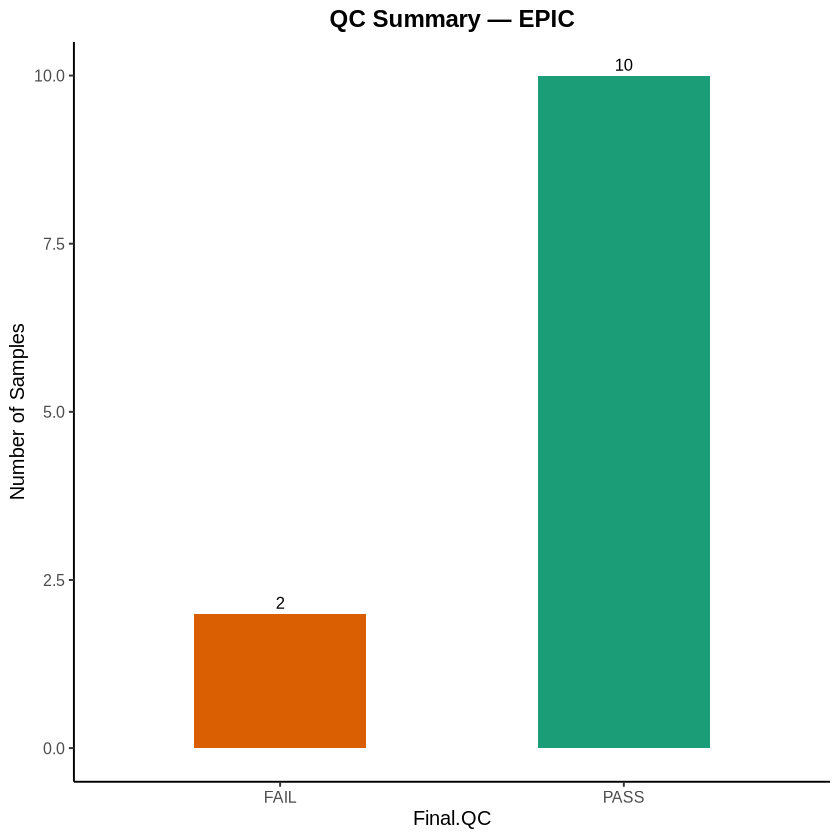

In [12]:
p_qc_bar <- plot(qcset, type = "qc_bar", outFile = NULL)
print(p_qc_bar)

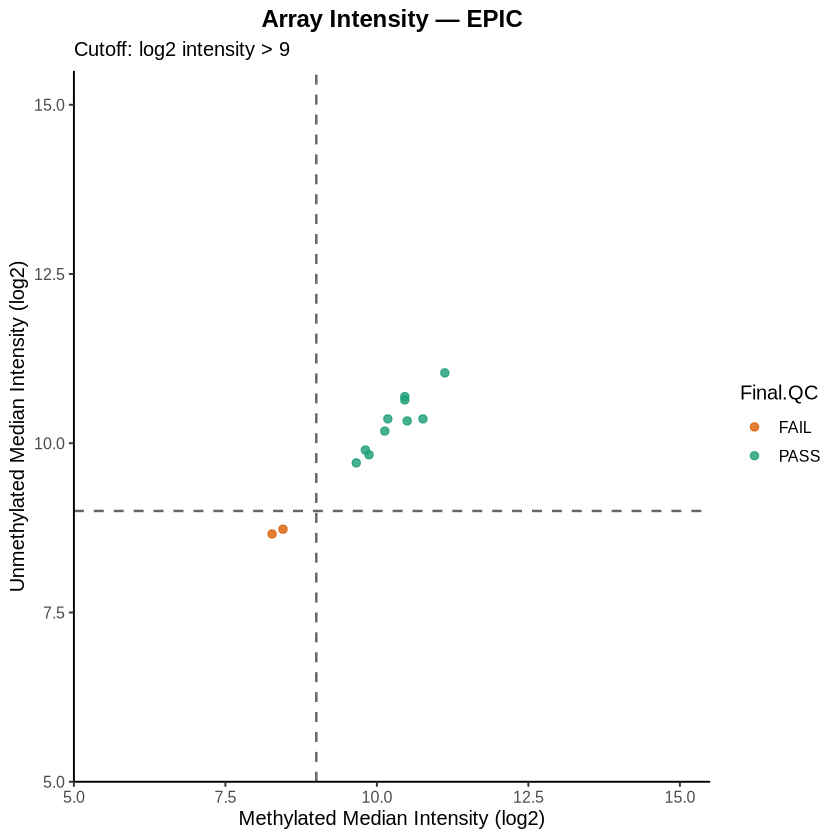

In [4]:
p_qc_intensity <- plot(qcset, type = "intensity", icutoff = 9, outFile = NULL)
print(p_qc_intensity)

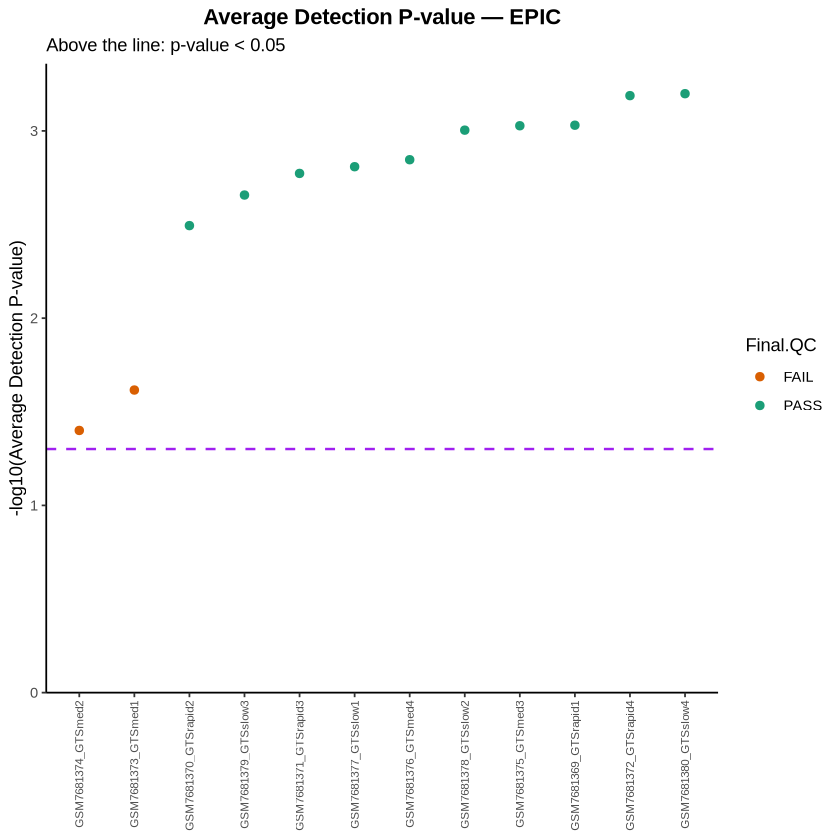

In [14]:
p_qc_detection <- plot(qcset, type = "detection_pval", pcutoff = 0.05, outFile = NULL)
print(p_qc_detection)

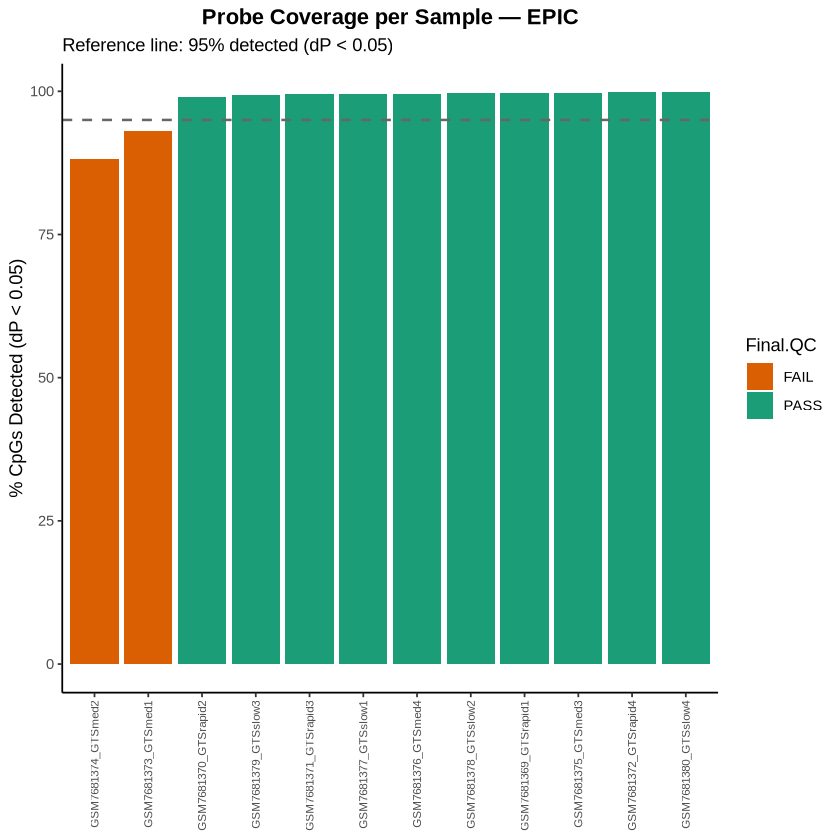

In [15]:
p_qc_coverage <- plot(qcset, type = "probe_coverage", outFile = NULL)
print(p_qc_coverage)


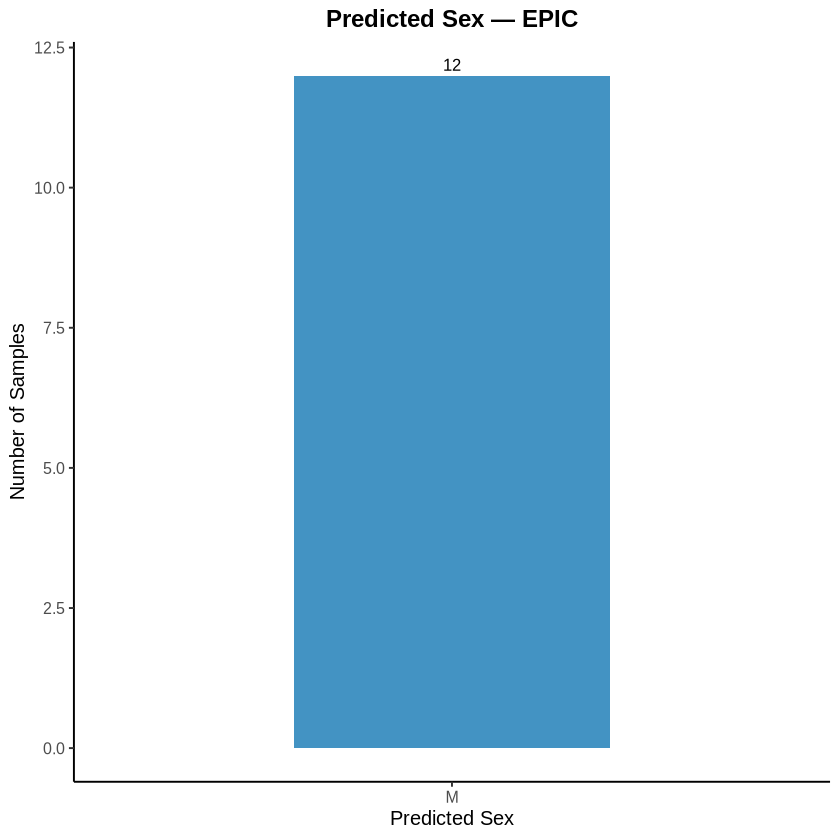

In [16]:
p_qc_sex <- plot(qcset, type = "predicted_sex", outFile = NULL)
print(p_qc_sex)

### Export QC outputs


In [21]:
qc_outdir <- "GSE240091_qc_output"
dir.create(qc_outdir, showWarnings = FALSE, recursive = TRUE)

export(
  qcset,
  outdir = qc_outdir,
  format = c("xlsx", "rds", "txt"),
  prefix = "GSE240091"
)

rds: wrote MethQcSet to GSE240091_qcset.rds





	[loaded existing workbook]

	[loaded existing workbook]


xlsx: wrote main qc tables to GSE240091_qc_table_main.xlsx





	[loaded existing workbook]


xlsx: wrote extra qc tables to GSE240091_qc_table_extra.xlsx

txt: wrote 6 text files

Exported 10 file(s) to GSE240091_qc_output



In [18]:
message("QC outputs exported to: ", qc_outdir)

QC outputs exported to: GSE240091_qc_output



## Phase 3: Prepare Beta Values for ImprintomeSet

### Use QC-clean beta values when available

If you ran the raw-IDAT QC workflow above, use PASS samples from `qcset`.

In [22]:
library("imprintomeR")
qcset <- readRDS("GSE240091_qc_output/GSE240091_qcset.rds")
qc_matrix <- qcset@qc_tables[["QC_matrix"]]
pass_samples <- qc_matrix$Sample_Name[qc_matrix$Final.QC == "PASS"]
head(pass_samples)

[1] "GSM7681369_GTSrapid1" "GSM7681370_GTSrapid2" "GSM7681371_GTSrapid3"
[4] "GSM7681372_GTSrapid4" "GSM7681375_GTSmed3"   "GSM7681376_GTSmed4"

In [9]:
qcset@qc_tables[["QC_matrix"]]

,SAMPLE_NAME,aveDetectionPval,DetPval.0.01,DetPval.0.05,pctDetectedCpG_dP0.01,pctDetectedCpG_dP0.05,Final.QC,mMed.Intensity,uMed.Intensity,aveMed.Intensity,predictedSex
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
GSM7681369_GTSrapid1,GSM7681369_GTSrapid1,0.0009323775,862282,863800,99.54,99.72,PASS,10.46,10.69,10.57,M
GSM7681370_GTSrapid2,GSM7681370_GTSrapid2,0.0032048086,852561,857374,98.42,98.98,PASS,9.66,9.71,9.69,M
GSM7681371_GTSrapid3,GSM7681371_GTSrapid3,0.0016869254,859265,861787,99.20,99.49,PASS,10.13,10.18,10.16,M
GSM7681372_GTSrapid4,GSM7681372_GTSrapid4,0.0006481207,863741,864624,99.71,99.81,PASS,11.12,11.04,11.08,M
GSM7681373_GTSmed1,GSM7681373_GTSmed1,0.0242046913,779588,806356,90.00,93.09,FAIL,8.45,8.73,8.59,M
GSM7681374_GTSmed2,GSM7681374_GTSmed2,0.0397871410,720786,763675,83.21,88.16,FAIL,8.27,8.66,8.46,M
GSM7681375_GTSmed3,GSM7681375_GTSmed3,0.0009386307,862313,863786,99.55,99.72,PASS,10.76,10.36,10.56,M
GSM7681376_GTSmed4,GSM7681376_GTSmed4,0.0014252495,860831,862776,99.38,99.60,PASS,10.18,10.36,10.27,M
GSM7681377_GTSslow1,GSM7681377_GTSslow1,0.0015531572,859476,862129,99.22,99.53,PASS,9.81,9.90,9.85,M


In [26]:
meta_pass <- meta(qcset)[match(pass_samples, meta(qcset)$Sample_Name), , drop = FALSE]
dim(meta_pass)


[1] 10  4

In [27]:
beta_pass <- beta(qcset)[, pass_samples, drop = FALSE]
dim(beta_pass)

[1] 866238     10

In [28]:
det_pval_pass <- if (!is.null(detection_pval(qcset))) {
  detection_pval(qcset)[, pass_samples, drop = FALSE]
} else {
  NULL
}

In [29]:
qc_tables_pass <- lapply(qc_tables(qcset), function(tbl) {
  if (is.data.frame(tbl) && "Sample_Name" %in% colnames(tbl)) {
    tbl[tbl$Sample_Name %in% pass_samples, , drop = FALSE]
  } else {
    tbl
  }
})

In [30]:
qcset_pass <- MethQcSet(
  meta = meta_pass,
  platform = platform(qcset),
  beta = beta_pass,
  detection_pval = det_pval_pass,
  qc_tables = qc_tables_pass,
  aggregation_status = aggregation_status(qcset),
  qc_params = qc_params(qcset)
)


In [32]:
saveRDS(qcset_pass, file=paste0(qc_outdir,"/GSE240091_qcset_pass.rds"))


In [33]:
x <- as.ImprintomeSet(
  qcset_pass,
  probeset = readRDS(system.file("extdata", "probesets_hg19.rds", package = "imprintomeR"))[["selected"]],
  genome = "hg19"
)

Note: Basename column dropped during conversion to ImprintomeSet (QC-specific, not needed for analysis).



## Phase 4: Run Workflow & Compute Statistics

### Execute imprintomeR analysis

In [36]:
message("Running imprintome analysis...")
x <- runImprintome(x, probeset = "selected", ids_cutoff = 0.2)
message("Analysis complete")

Running imprintome analysis...




	[meta dim: 10 x 3 ]
	[beta dim: 866238 x 11 ]
	[meta dim: 10 x 3 ]
	[beta dim: 866238 x 10 ]
	[SubsetBeta] subset by probeset [query: 669; matched probes: 619 ]


Analysis complete



In [37]:
res <- results(x)
message("Results available:")
print(names(res))

status <- res[["AnalyzeImprintStatus.selected"]]
head(status, n = 5)

Results available:



[1] "AnalyzeImprintStatus.selected"


,Sample_Name,Sample_Group,probeset,paternal_median,maternal_median,pat_cons,mat_cons,consistency,IDS,Angle,Mechanism,Status,Confidence
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
GSM7681369_GTSrapid1,GSM7681369_GTSrapid1,GTSrapid,selected,0.578,0.272,0.6071429,0.8778004,0.7424716,0.241,288.9,Mat-Loss,Imprinting Alteration,Moderate (Alteration)
GSM7681370_GTSrapid2,GSM7681370_GTSrapid2,GTSrapid,selected,0.703,0.198,0.7142857,0.8024440,0.7583649,0.364,303.9,Pat-Gain+Mat-Loss,Imprinting Alteration,Moderate (Alteration)
GSM7681371_GTSrapid3,GSM7681371_GTSrapid3,GTSrapid,selected,0.478,0.194,0.5357143,0.8513238,0.6935191,0.306,266.0,Mat-Loss,Imprinting Alteration,Moderate (Alteration)
GSM7681372_GTSrapid4,GSM7681372_GTSrapid4,GTSrapid,selected,0.472,0.308,0.6160714,0.7942974,0.7051844,0.194,261.6,ROI,Normal,Low (Normal)
GSM7681375_GTSmed3,GSM7681375_GTSmed3,GTSmedium,selected,0.649,0.282,0.6785714,0.8085540,0.7435627,0.265,304.4,Pat-Gain+Mat-Loss,Imprinting Alteration,Moderate (Alteration)


### Compute per-group statistics


In [38]:
message("Imprinting status by group:")
print(table(status[, c("Sample_Group", "Mechanism")]))

stat_summary <- status %>%
  group_by(Sample_Group, Mechanism) %>%
  summarize(
    n = n(),
    median_IDS = median(IDS, na.rm = TRUE),
    median_Angle = median(Angle, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(Sample_Group, desc(n))

stat_summary

Imprinting status by group:



            Mechanism
Sample_Group Global-Hypo Mat-Loss Pat-Gain+Mat-Loss ROI
   GTSmedium           1        0                 1   0
   GTSrapid            0        2                 1   1
   GTSslow             0        3                 0   1


Sample_Group,Mechanism,n,median_IDS,median_Angle
<chr>,<chr>,<int>,<dbl>,<dbl>
GTSmedium,Global-Hypo,1,0.4120,237.10
GTSmedium,Pat-Gain+Mat-Loss,1,0.2650,304.40
GTSrapid,Mat-Loss,2,0.2735,277.45
GTSrapid,Pat-Gain+Mat-Loss,1,0.3640,303.90
GTSrapid,ROI,1,0.1940,261.60
GTSslow,Mat-Loss,3,0.2630,258.00
GTSslow,ROI,1,0.0630,301.80


### Review key metrics

In [39]:
message("IDS distribution:")
print(summary(status$IDS))

message("\nMechanism classification:")
print(table(status$Mechanism))

message("\nAngle distribution:")
print(summary(status$Angle))

IDS distribution:



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0630  0.2447  0.2640  0.2631  0.2963  0.4120 



Mechanism classification:




      Global-Hypo          Mat-Loss Pat-Gain+Mat-Loss               ROI 
                1                 5                 2                 2 



Angle distribution:



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  237.1   258.9   269.3   274.7   298.6   304.4 



## Phase 5: Visualizations

In [40]:
sample_id_1 <- colnames(beta(x))[2]
message("Representative sample for single-sample plots: ", sample_id_1)

Representative sample for single-sample plots: GSM7681370_GTSrapid2



### Plot 1: Polar scatter

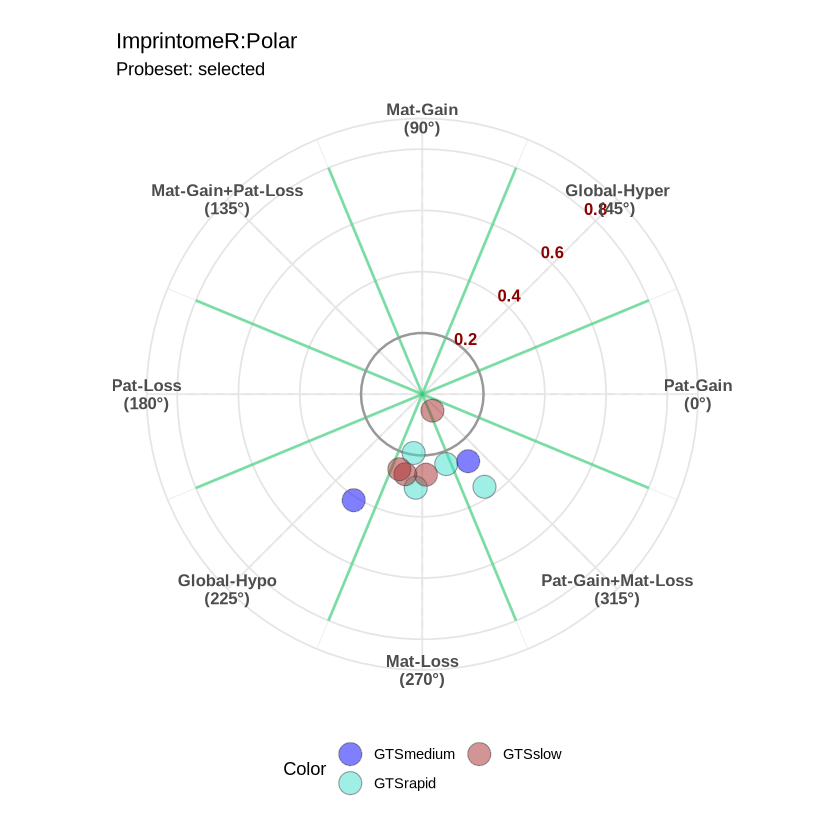

In [42]:
p_polar <- plot(
  x,
  plot_type = "polar",
  result_name = "AnalyzeImprintStatus.selected",
  colorColumn = "Sample_Group",
  outFile = NULL
)
print(p_polar)

### Plot 2: Beeswarm by origin

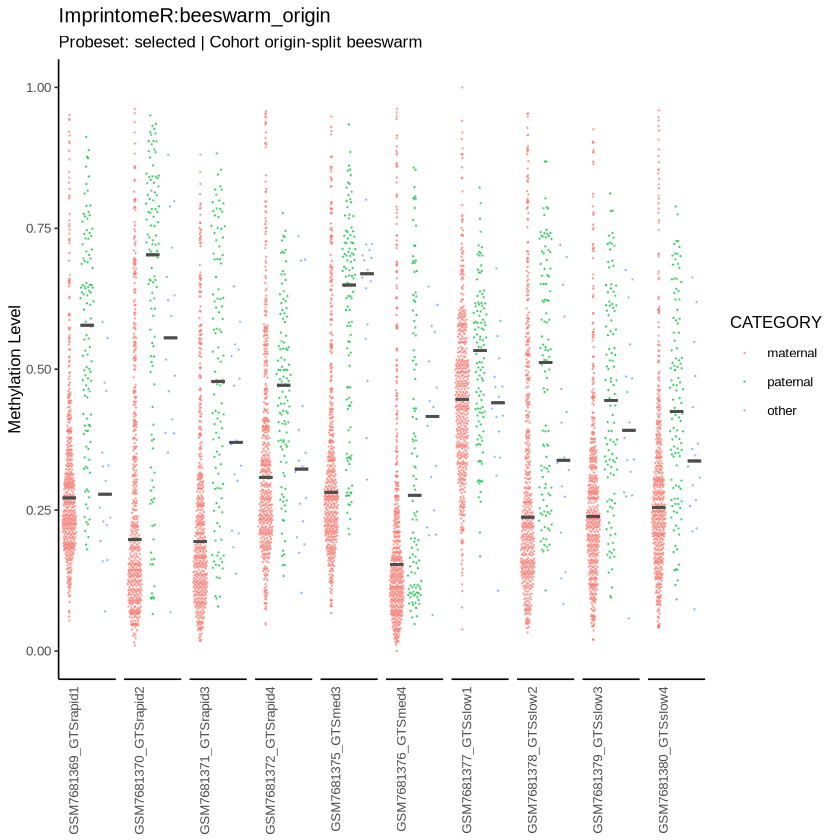

In [43]:
p_beeswarm_origin <- plot(
  x,
  plot_type = "beeswarm_origin",
  probeset = "selected",
  SAMPLEID = "Sample_Name",
  outFile = NULL
)
print(p_beeswarm_origin)

### Plot 3: Mirror density


	[SubsetBeta] subset by probeset [query: 669; matched probes: 619 ]


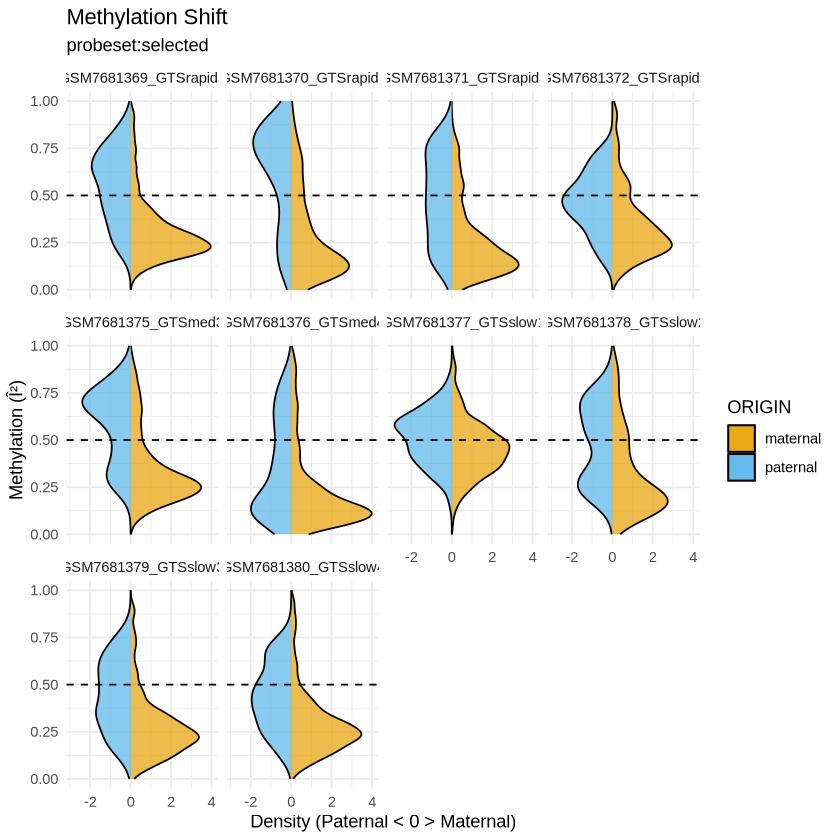

In [44]:
p_mirror <- plot(
  x,
  plot_type = "mirror_density",
  probeset = "selected",
  outFile = NULL
)


### Plot 4: Circular heatmap


INFO:  number of annotated probes is  619 
[1] "GTSrapid"  "GTSmedium" "GTSslow"  
           CHR  MAPINFO   GENE
cg10243676   1 40024971  PPIEL
cg11704876   1 40025232       
cg03641225   1 68512539 DIRAS3
cg24871743   1 68512650 DIRAS3
cg22901840   1 68512777 DIRAS3
cg20149168   1 68512807 DIRAS3
[1] "GTSrapid"  "GTSmedium" "GTSslow"  
  sector   x row_ind
1      1 0.5       1
2      1 1.5       2
3      1 2.5       3
4      1 3.5       4
5      1 4.5       5
6      1 5.5       6

INFO: process section # 1 GTSrapid 


Note: 1 point is out of plotting region in sector '22', track '5'.

Note: 8 points are out of plotting region in sector '22', track '5'.




INFO: process section # 2 GTSmedium 


Note: 1 point is out of plotting region in sector '22', track '6'.

Note: 9 points are out of plotting region in sector '22', track '6'.




INFO: process section # 3 GTSslow 


Note: 1 point is out of plotting region in sector '22', track '7'.

Note: 7 points are out of plotting region in sector '22', track '7'.



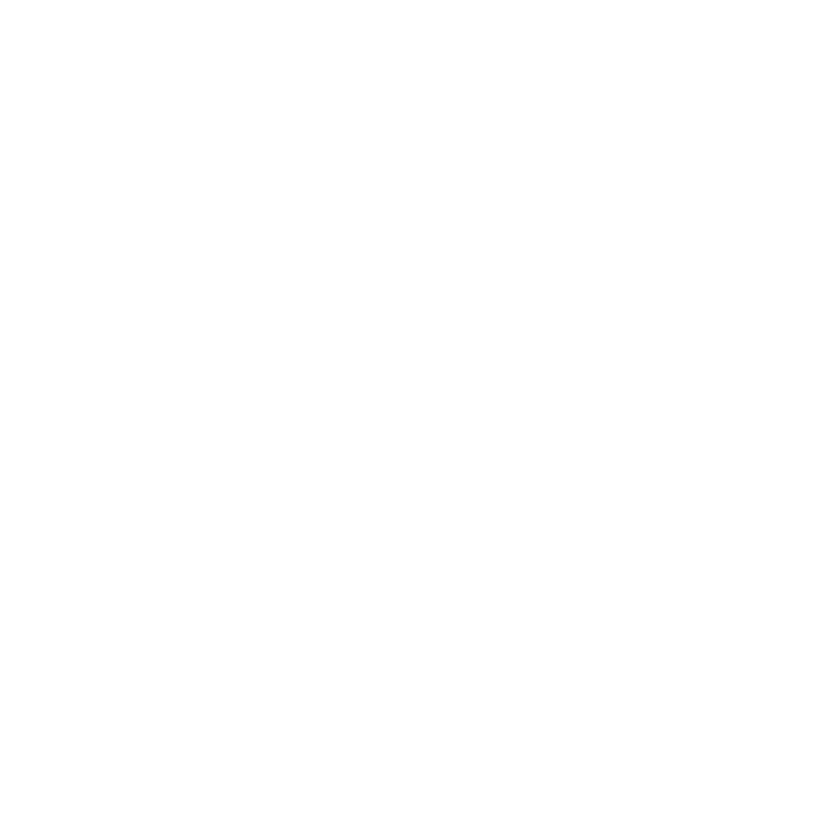

NULL

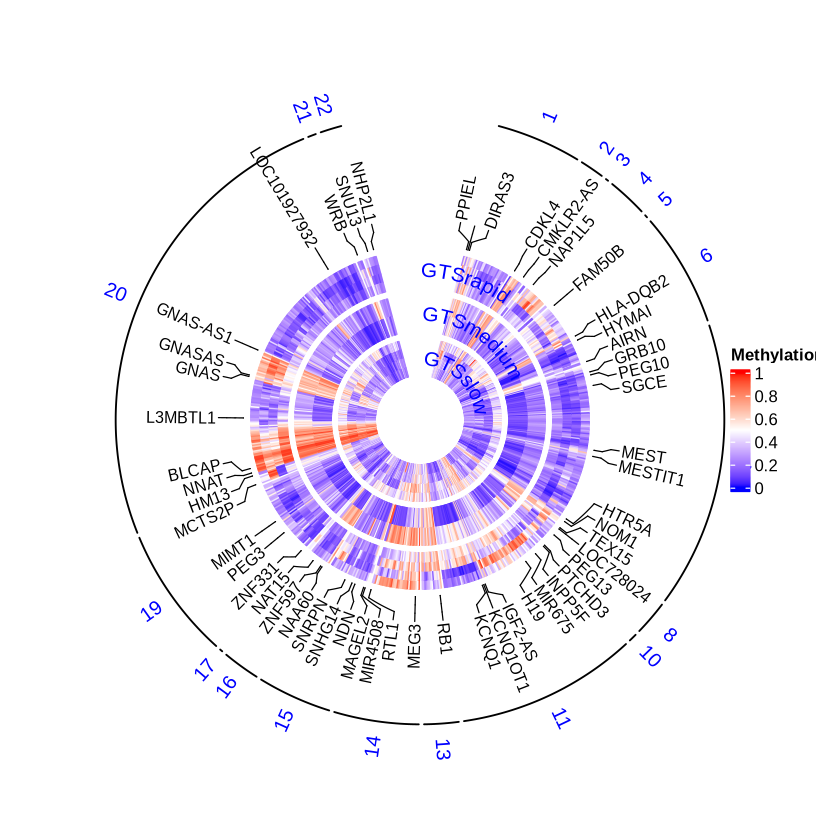

In [51]:
p_circular <- plot(
  x,
  plot_type = "circular_heatmap",
  probeset = "selected",
  outFile = NULL
)
p_circular


### Plot 5: Beta heatmap by probe


In [55]:
p_heatmap <- plot(
  x,
  plot_type = "heatmap_by_probe",
  probeset = "selected",
  SAMPLEID = "Sample_Name",
  annoColumn = "Sample_Group",
  outFile = NULL
)

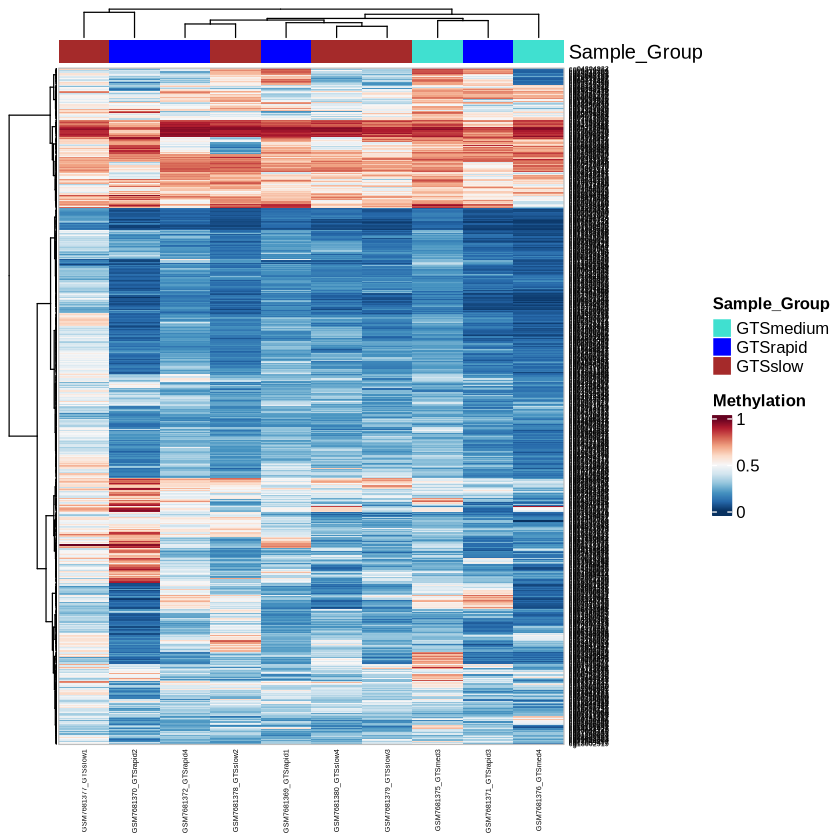

In [56]:
draw(p_heatmap, merge_legend = TRUE)

### Plot 6: Beta heatmap by gene

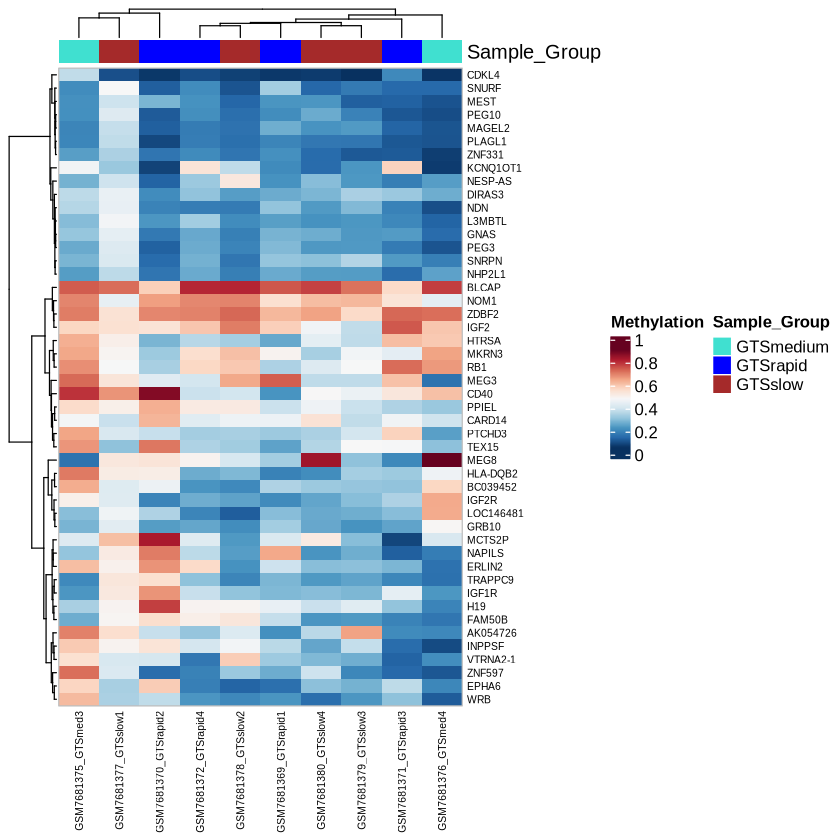

In [59]:
p_heatmap_by_gene <- plot(
  x,
  plot_type = "heatmap_by_gene",
  probeset = "selected",
  SAMPLEID = "Sample_Name",
  annoColumn = "Sample_Group",
  clusterRows = TRUE,
  clusterColumns = TRUE,
  outFile = NULL
)
print(p_heatmap_by_gene)

In [61]:
unloadNamespace("imprintomeR")
library(imprintomeR)



Attaching package: ‘imprintomeR’


The following objects are masked from ‘package:SummarizedExperiment’:

    assay, assay<-


The following objects are masked from ‘package:GenomeInfoDb’:

    genome, genome<-


The following object is masked from ‘package:dplyr’:

    summarize


The following object is masked from ‘package:base’:

    beta





### Plot 7: Radar plot

In [64]:
p_radar <- plot(
  x,
  plot_type = "radar",
  sample_id = sample_id_1,
  probeset = "selected",
  outFile = NULL
)


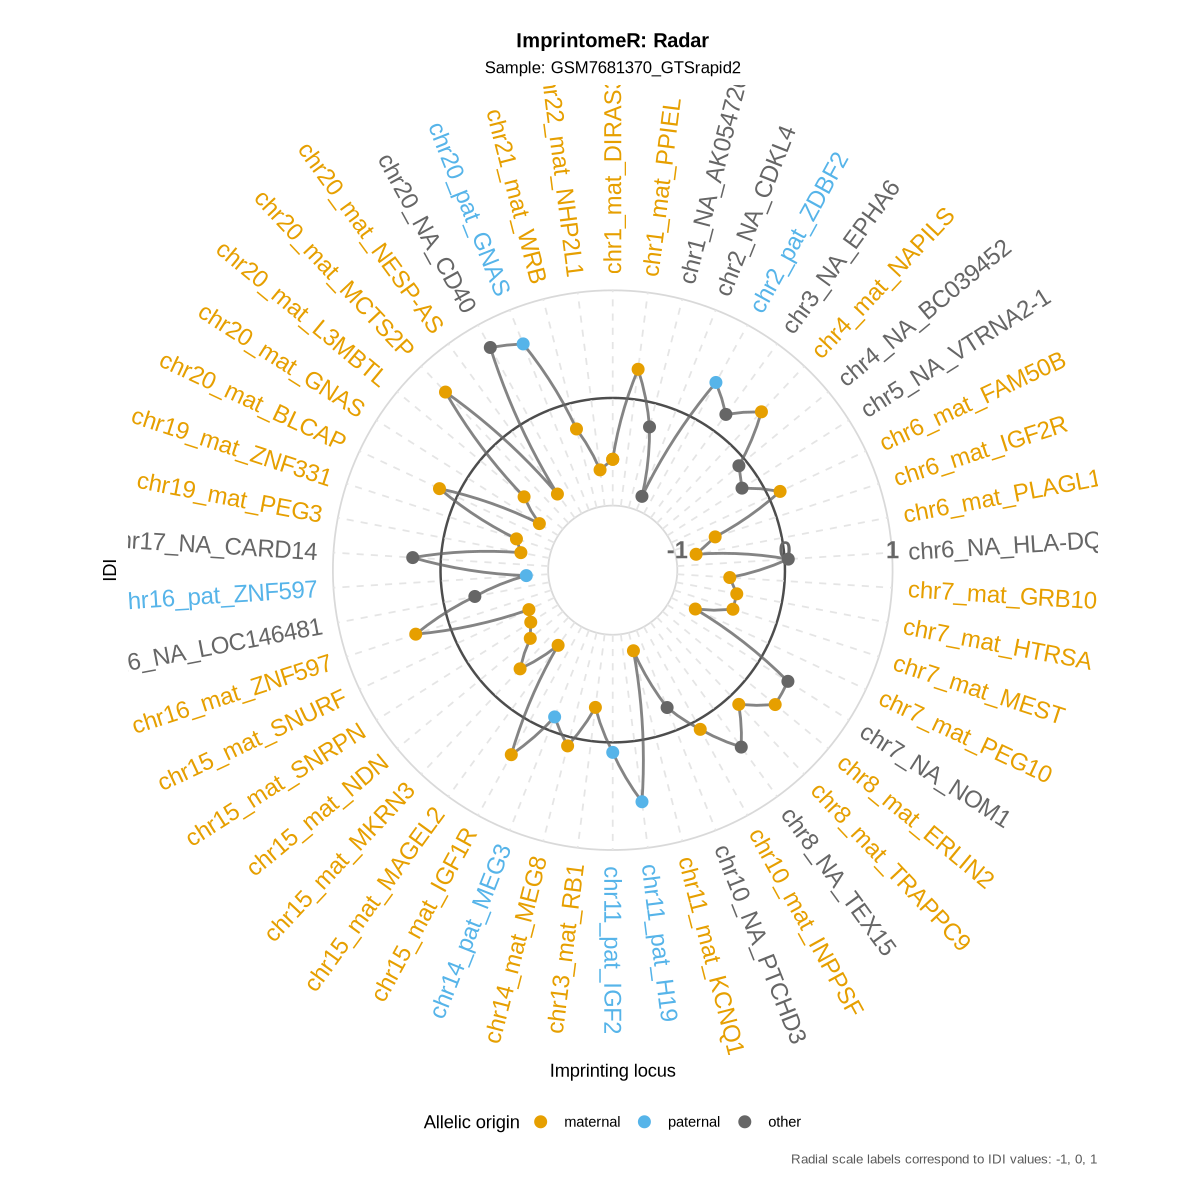

In [63]:
options(repr.plot.width = 10, repr.plot.height = 10) 
print(p_radar)


### Plot 8: Beeswarm by chromosome

In [65]:
p_beeswarm_chr <- plot(
  x,
  plot_type = "beeswarm_chr",
  sample_id = sample_id_1,
  probeset = "selected",
  outFile = NULL
)

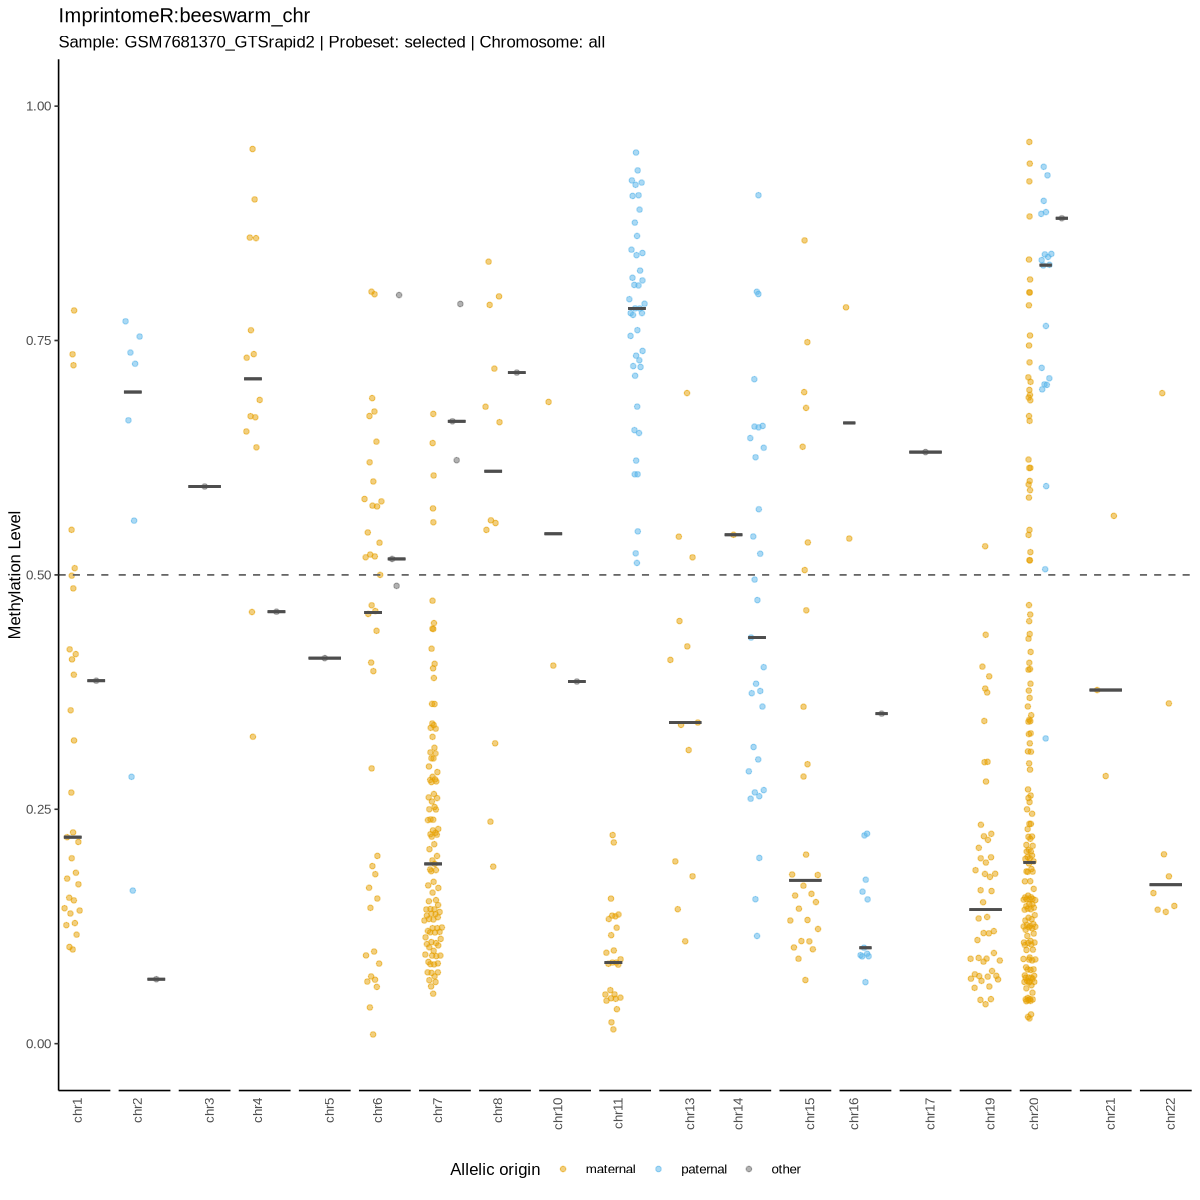

In [66]:
print(p_beeswarm_chr)

### Plot 9: Rainfall plot

In [67]:
p_rainfall <- plot(
  x,
  plot_type = "rainfall",
  sample_id = sample_id_1,
  probeset = "classifier3",
  outFile = NULL
)

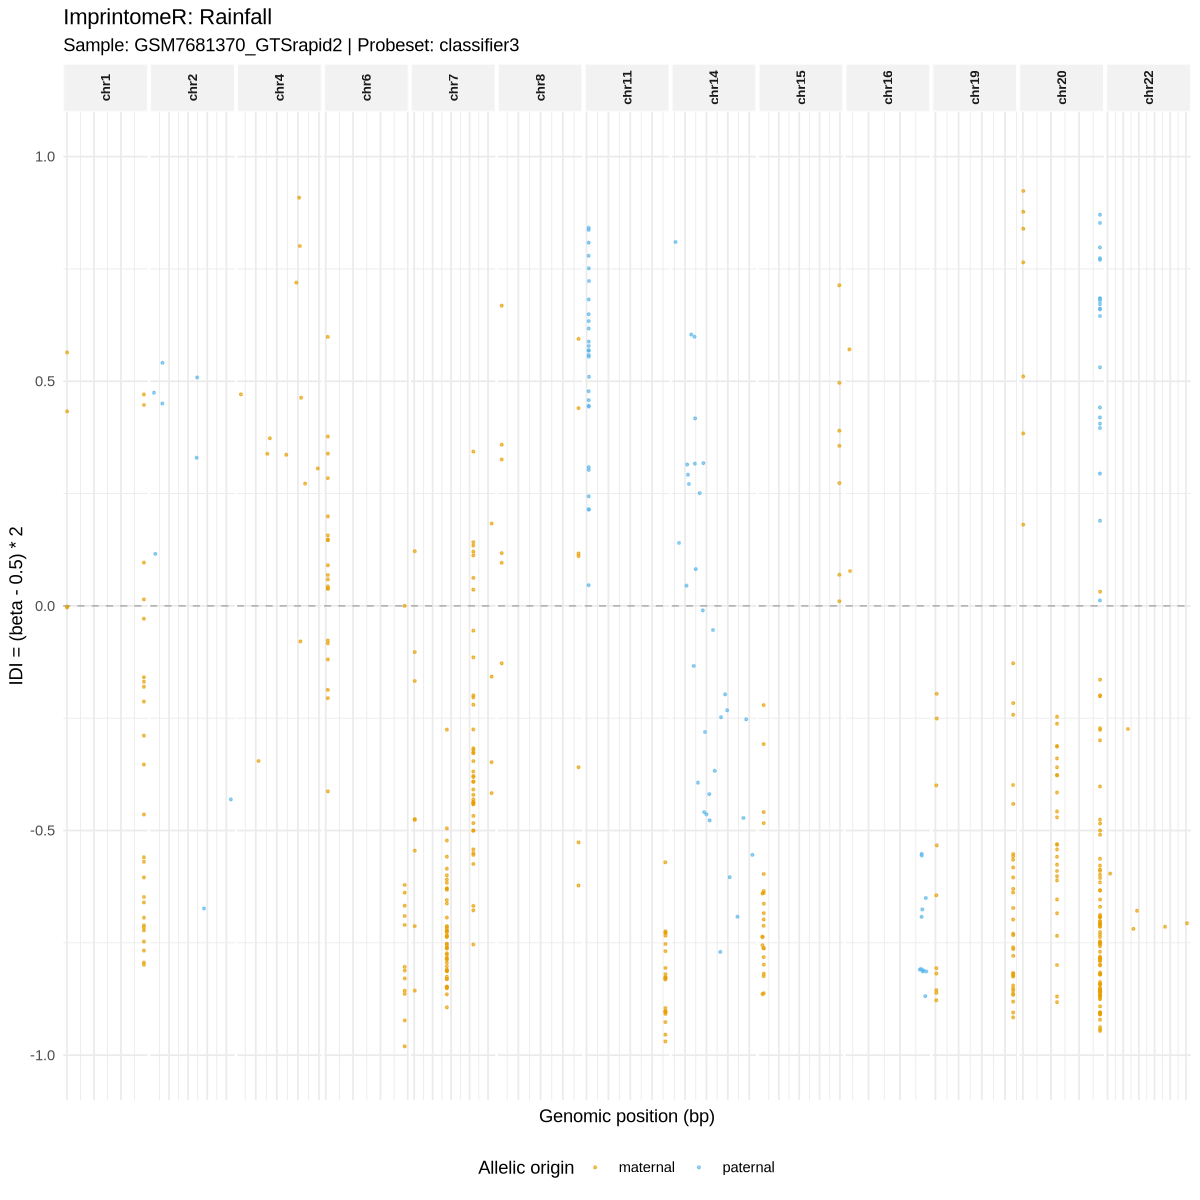

In [68]:
print(p_rainfall)

## Phase 6: Results Interpretation


In [69]:
normal_n <- sum(status$Mechanism == "NORMAL", na.rm = TRUE)
total_n <- nrow(status)
normal_pct <- normal_n / total_n * 100
abnormal_pct <- 100 - normal_pct

message("=== OVERALL IMPRINTING SUMMARY ===")
message(sprintf("Normal imprinting:   %6.1f%% (%d/%d samples)",
                normal_pct, normal_n, total_n))
message(sprintf("Altered imprinting:  %6.1f%% (%d/%d samples)",
                abnormal_pct, total_n - normal_n, total_n))

message("\n=== BY SAMPLE GROUP ===")
for (group in unique(status$Sample_Group)) {
  idx <- status$Sample_Group == group
  n <- sum(idx)
  normal <- sum(status$Mechanism[idx] == "NORMAL", na.rm = TRUE)
  message(sprintf("%12s: %d samples, %d normal (%.1f%%)",
                  group, n, normal, 100 * normal / n))
}

=== OVERALL IMPRINTING SUMMARY ===

Normal imprinting:      0.0% (0/10 samples)

Altered imprinting:   100.0% (10/10 samples)


=== BY SAMPLE GROUP ===

    GTSrapid: 4 samples, 0 normal (0.0%)

   GTSmedium: 2 samples, 0 normal (0.0%)

     GTSslow: 4 samples, 0 normal (0.0%)



### Identify samples with aberrant imprinting


In [71]:
abnormal <- status %>% filter(Mechanism != "NORMAL")

sample_col <- intersect(c("Sample_Name", "Sample_ID"), colnames(status))[1]

if (nrow(abnormal) > 0) {
  message("=== ABERRANT IMPRINTING SAMPLES ===")
  message("Sample count: ", nrow(abnormal))
  print(abnormal %>% select(all_of(sample_col), Sample_Group, Mechanism, IDS, Angle) %>% head(n = 12))
} else {
  message("All samples show normal imprinting patterns by the selected IDS cutoff.")
}

=== ABERRANT IMPRINTING SAMPLES ===

Sample count: 10



                              Sample_Name Sample_Group         Mechanism   IDS
GSM7681369_GTSrapid1 GSM7681369_GTSrapid1     GTSrapid          Mat-Loss 0.241
GSM7681370_GTSrapid2 GSM7681370_GTSrapid2     GTSrapid Pat-Gain+Mat-Loss 0.364
GSM7681371_GTSrapid3 GSM7681371_GTSrapid3     GTSrapid          Mat-Loss 0.306
GSM7681372_GTSrapid4 GSM7681372_GTSrapid4     GTSrapid               ROI 0.194
GSM7681375_GTSmed3     GSM7681375_GTSmed3    GTSmedium Pat-Gain+Mat-Loss 0.265
GSM7681376_GTSmed4     GSM7681376_GTSmed4    GTSmedium       Global-Hypo 0.412
GSM7681377_GTSslow1   GSM7681377_GTSslow1      GTSslow               ROI 0.063
GSM7681378_GTSslow2   GSM7681378_GTSslow2      GTSslow          Mat-Loss 0.263
GSM7681379_GTSslow3   GSM7681379_GTSslow3      GTSslow          Mat-Loss 0.267
GSM7681380_GTSslow4   GSM7681380_GTSslow4      GTSslow          Mat-Loss 0.256
                     Angle
GSM7681369_GTSrapid1 288.9
GSM7681370_GTSrapid2 303.9
GSM7681371_GTSrapid3 266.0
GSM7681372_GTSrapid4 26


### Key findings template

In [73]:
message("=== KEY BIOLOGICAL INSIGHTS TEMPLATE ===")
message("1. Dataset: GSE240091, growing teratoma tissue methylation cohort")
message("2. Platform: Illumina HumanMethylationEPIC / 850K")
message("3. Samples analyzed: ", nrow(status))
message("4. IDS range: [",
        round(min(status$IDS, na.rm = TRUE), 3), ", ",
        round(max(status$IDS, na.rm = TRUE), 3), "]")
message("5. Most common mechanism: ",
        names(sort(table(status$Mechanism), decreasing = TRUE))[1])
message("6. Use growth_summary and detailed_status to compare imprinting metrics across growth-speed groups.")

=== KEY BIOLOGICAL INSIGHTS TEMPLATE ===

1. Dataset: GSE240091, growing teratoma tissue methylation cohort

2. Platform: Illumina HumanMethylationEPIC / 850K

3. Samples analyzed: 10

4. IDS range: [0.063, 0.412]

5. Most common mechanism: Mat-Loss

6. Use growth_summary and detailed_status to compare imprinting metrics across growth-speed groups.



## Phase 7: Export & Save Results

### Export ImprintomeSet outputs

In [76]:
manifest <- export(
  x,
  outdir = "GSE240091_imprintome_output",
  result_names = "AnalyzeImprintStatus.selected",
  save_plots = FALSE,
  plot_device = "pdf",
  overwrite = TRUE
)

head(manifest)

,category,name,file,status
,<chr>,<chr>,<chr>,<chr>
1,results,AnalyzeImprintStatus.selected,GSE240091_imprintome_output/results_AnalyzeImprintStatus.selected.tsv,written


## Session Information & Reproducibility


In [77]:
message("=== REPRODUCIBILITY ===")
message("R version: ", R.version$version.string)
message("imprintomeR version: ", packageVersion("imprintomeR"))
message("Execution date: ", Sys.Date())
message("Random seed: 2026")

sessionInfo()

=== REPRODUCIBILITY ===

R version: R version 4.2.3 (2023-03-15)

imprintomeR version: 1.0

Execution date: 2026-06-24

Random seed: 2026



R version 4.2.3 (2023-03-15)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 8.10 (Ootpa)

Matrix products: default
BLAS/LAPACK: /research/rgs01/home/clusterHome/hjin/.jupyter-on-the-cluster-env/lib/libopenblasp-r0.3.30.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
 [1] parallel  stats4    grid      stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] imprintomeR_1.0                                    
 [2] RColorBrewer_1.1-3                                 
 [3] edgeR_3.40.2                                       
 [4] limma_3.54.2                               